<a href="https://colab.research.google.com/github/yucelasan/superstore/blob/main/Final_Market_3A_Superstore_Gelir_Tahminleri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import auth
auth.authenticate_user()
from google.cloud import bigquery

import pandas as pd

client = bigquery.Client(project="superstore-484710")

**BigQuery query**

In [ ]:
query = """
SELECT
  order_id,
  order_date,
  total_basket,
  branch_id
FROM `superstore-484710.dbt_superstore_int_superstore.int_orders_market`
"""
df = client.query(query).to_dataframe()


In [ ]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10235193 entries, 0 to 10235192
Data columns (total 4 columns):
 #   Column        Dtype  
---  ------        -----  
 0   order_id      Int64  
 1   order_date    dbdate 
 2   total_basket  float64
 3   branch_id     object 
dtypes: Int64(1), dbdate(1), float64(1), object(1)
memory usage: 322.1+ MB


**Market (branch) bazında günlük tahmin**

Temizlik

In [ ]:
import pandas as pd
import numpy as np

df["order_date"] = pd.to_datetime(df["order_date"])
df["total_basket"] = pd.to_numeric(df["total_basket"], errors="coerce").fillna(0)

df = df.dropna(subset=["branch_id"])
df["branch_id"] = df["branch_id"].astype(str)

df.head(), df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10235193 entries, 0 to 10235192
Data columns (total 4 columns):
 #   Column        Dtype         
---  ------        -----         
 0   order_id      Int64         
 1   order_date    datetime64[ns]
 2   total_basket  float64       
 3   branch_id     object        
dtypes: Int64(1), datetime64[ns](1), float64(1), object(1)
memory usage: 322.1+ MB


(   order_id order_date  total_basket branch_id
 0   6053238 2023-02-23       4010.18   739-KI2
 1   2932801 2022-12-20      15187.34   739-KI2
 2   7797989 2023-01-09      14361.82   741-KO3
 3   5990118 2021-02-10      12568.45   754-SA1
 4   2474116 2022-12-10       7730.12   754-SA1,
 None)

Günlük branch aggregate (city/region sabit kolon olarak taşınacak)

In [ ]:
daily_branch = (
    df.groupby(
        ["branch_id", pd.Grouper(key="order_date", freq="D")],
        as_index=False
    )
    .agg(total_revenue=("total_basket", "sum"))
)

daily_branch = daily_branch.rename(
    columns={"order_date": "ds", "total_revenue": "y"}
).sort_values(["branch_id", "ds"]).reset_index(drop=True)

daily_branch.head()

,branch_id,ds,y
0,11-AD1,2021-01-01,217742.33
1,11-AD1,2021-01-02,184294.96
2,11-AD1,2021-01-03,168766.32
3,11-AD1,2021-01-04,140352.94
4,11-AD1,2021-01-05,189175.46


**Branch bazlı Prophet tahmini (15.08.2023 – 31.12.2023)**

Kritik nokta:
– Veri az olan branch’lerde Prophet saçmalar
– Bu yüzden fallback (son 14 gün ortalaması) kullandık

In [ ]:
from prophet import Prophet

FORECAST_START = pd.Timestamp("2023-08-15")
FORECAST_END   = pd.Timestamp("2023-12-31")
min_days_for_prophet = 60

results = []

branch_ids = daily_branch["branch_id"].unique()

for b in branch_ids:
    g = daily_branch[daily_branch["branch_id"] == b].copy()

    # 1️⃣ Actual veriler
    actual_part = g[g["ds"] < FORECAST_START].copy()
    if not actual_part.empty:
        actual_part["data_type"] = "actual"
        actual_part = actual_part.rename(columns={"y": "revenue"})
        results.append(
            actual_part[["branch_id", "ds", "revenue", "data_type"]]
        )

    # 2️⃣ Train set
    train = g[g["ds"] < FORECAST_START][["ds", "y"]].dropna()

    # 3️⃣ Fallback: veri azsa düz seviye tahmin
    if train["ds"].nunique() < min_days_for_prophet:
        level = train.tail(14)["y"].mean() if not train.empty else 0

        future_days = pd.date_range(FORECAST_START, FORECAST_END, freq="D")
        fc = pd.DataFrame({
            "branch_id": b,
            "ds": future_days,
            "revenue": level,
            "data_type": "forecast"
        })
        results.append(fc)
        continue

    # 4️⃣ Prophet modeli
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.1
    )
    model.fit(train)

    future = pd.DataFrame({
        "ds": pd.date_range(train["ds"].min(), FORECAST_END, freq="D")
    })

    forecast = model.predict(future)

    forecast_part = forecast[
        (forecast["ds"] >= FORECAST_START) &
        (forecast["ds"] <= FORECAST_END)
    ][["ds", "yhat"]].copy()

    forecast_part["revenue"] = forecast_part["yhat"].clip(lower=0)
    forecast_part["branch_id"] = b
    forecast_part["data_type"] = "forecast"

    results.append(
        forecast_part[["branch_id", "ds", "revenue", "data_type"]]
    )

**Final tablo (branch bazlı daily actual + forecast)**

In [ ]:
final_daily_branch = (
    pd.concat(results, ignore_index=True)
      .sort_values(["branch_id", "ds"])
      .reset_index(drop=True)
)

final_daily_branch.head()
final_daily_branch.tail()
final_daily_branch.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176290 entries, 0 to 176289
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   branch_id  176290 non-null  object        
 1   ds         176290 non-null  datetime64[ns]
 2   revenue    176290 non-null  float64       
 3   data_type  176290 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 5.4+ MB


**Hızlı kontrol (1 branch grafiği)**

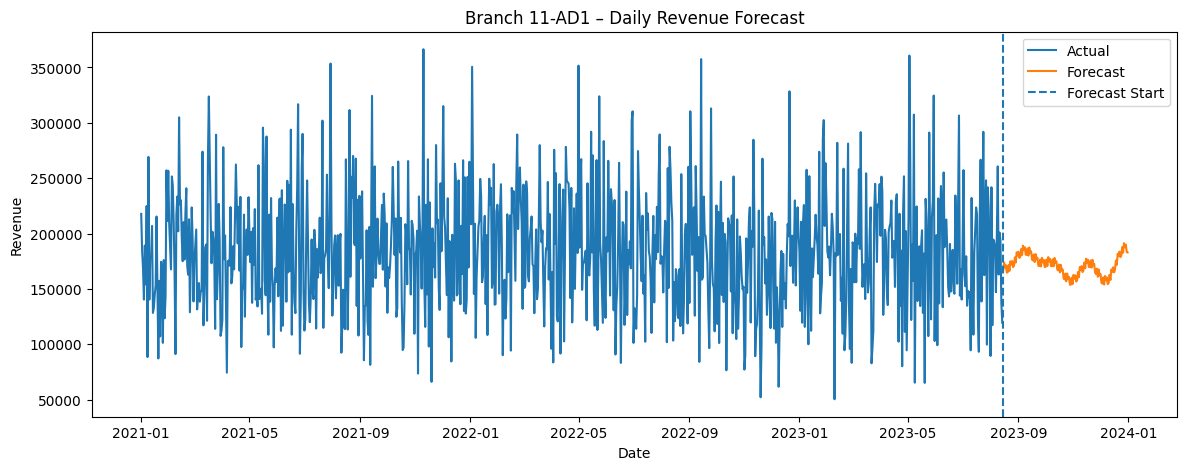

In [ ]:
import matplotlib.pyplot as plt

sample_branch = final_daily_branch["branch_id"].value_counts().index[0]
tmp = final_daily_branch[final_daily_branch["branch_id"] == sample_branch]

plt.figure(figsize=(14,5))
plt.plot(tmp[tmp["data_type"]=="actual"]["ds"],
         tmp[tmp["data_type"]=="actual"]["revenue"], label="Actual")
plt.plot(tmp[tmp["data_type"]=="forecast"]["ds"],
         tmp[tmp["data_type"]=="forecast"]["revenue"], label="Forecast")

plt.axvline(FORECAST_START, linestyle="--", label="Forecast Start")
plt.title(f"Branch {sample_branch} – Daily Revenue Forecast")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()

In [ ]:
PROJECT_ID = "superstore-484710"
DATASET_ID = "dbt_superstore_mart"
TABLE_ID = "branch_daily_revenue_actual_forecast"

TABLE_FULL = f"{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}"


In [ ]:
from google.cloud import bigquery

client = bigquery.Client(project=PROJECT_ID)

job = client.load_table_from_dataframe(
    final_daily_branch,
    TABLE_FULL,
    job_config=bigquery.LoadJobConfig(
        write_disposition="WRITE_TRUNCATE"  # her çalıştırmada yeniler
    )
)

job.result()


LoadJob<project=superstore-484710, location=EU, id=b1c1edde-26cc-4744-abf9-cf6bc41071b8>

In [ ]:
VAL_TRAIN_END = pd.Timestamp("2023-06-30")
VAL_TEST_START = pd.Timestamp("2023-07-01")
VAL_TEST_END = pd.Timestamp("2023-07-31")

In [ ]:
from prophet import Prophet
import numpy as np

validation_rows = []

for b in daily_branch["branch_id"].unique():
    g = daily_branch[daily_branch["branch_id"] == b].copy()

    train = g[g["ds"] <= VAL_TRAIN_END][["ds", "y"]]
    test  = g[(g["ds"] >= VAL_TEST_START) & (g["ds"] <= VAL_TEST_END)][["ds", "y"]]

    # minimum veri kontrolü
    if train["ds"].nunique() < 60 or len(test) == 0:
        continue

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.1
    )
    model.fit(train)

    future = pd.DataFrame({"ds": test["ds"]})
    forecast = model.predict(future)

    merged = test.merge(
        forecast[["ds", "yhat"]],
        on="ds",
        how="left"
    )

    merged["branch_id"] = b
    validation_rows.append(merged)

validation_df = pd.concat(validation_rows, ignore_index=True)
validation_df.head()

,ds,y,yhat,branch_id
0,2023-07-01,187818.92,168596.996930,11-AD1
1,2023-07-02,257283.73,167257.565858,11-AD1
2,2023-07-03,163553.92,174495.990906,11-AD1
3,2023-07-04,152414.32,168317.295342,11-AD1
4,2023-07-05,179429.12,174717.518603,11-AD1


In [ ]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [ ]:
metrics_daily_branch = (
    validation_df
    .groupby("branch_id")
    .apply(lambda x: pd.Series({
        "MAPE_pct": mape(x["y"], x["yhat"]),
        "MAE": np.mean(np.abs(x["y"] - x["yhat"])),
        "RMSE": np.sqrt(np.mean((x["y"] - x["yhat"])**2)),
        "Bias": np.mean(x["yhat"] - x["y"])
    }))
    .reset_index()
)

metrics_daily_branch.head()

/tmp/ipython-input-1989816512.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,branch_id,MAPE_pct,MAE,RMSE,Bias
0,11-AD1,26.823370,43314.592478,51605.488307,-5425.780148
1,11-AD2,14.783752,57205.321324,68289.405013,2616.548608
2,11-AD3,9.063021,173217.890338,191540.316016,9453.427476
3,11-AD4,52.555576,21762.904587,24543.302965,4340.127122
4,115-BU1,18.014233,49018.166028,63292.203459,3374.880737


In [ ]:
overall_daily_metrics = {
    "MAPE_pct": mape(validation_df["y"], validation_df["yhat"]),
    "MAE": np.mean(np.abs(validation_df["y"] - validation_df["yhat"])),
    "RMSE": np.sqrt(np.mean((validation_df["y"] - validation_df["yhat"])**2)),
    "Bias": np.mean(validation_df["yhat"] - validation_df["y"])
}

overall_daily_metrics

{'MAPE_pct': np.float64(17.983997245283337),
 'MAE': np.float64(66646.39369562837),
 'RMSE': np.float64(94374.18770508871),
 'Bias': np.float64(-1259.526097293042)}

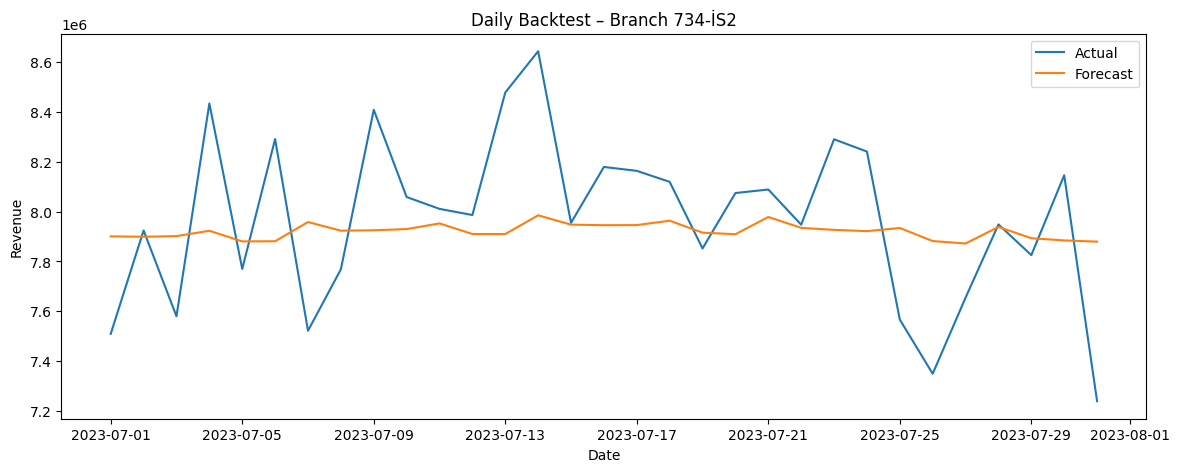

In [ ]:
import matplotlib.pyplot as plt

sample_branch = metrics_daily_branch.sort_values("MAPE_pct").iloc[0]["branch_id"]

tmp = validation_df[validation_df["branch_id"] == sample_branch]

plt.figure(figsize=(14,5))
plt.plot(tmp["ds"], tmp["y"], label="Actual")
plt.plot(tmp["ds"], tmp["yhat"], label="Forecast")
plt.title(f"Daily Backtest – Branch {sample_branch}")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()

**Branch bazlı AYLIK gelir**

In [ ]:
monthly_branch = (
    final_daily_branch
    .groupby(
        [
            "branch_id",
            pd.Grouper(key="ds", freq="M"),
            "data_type"
        ],
        as_index=False
    )
    .agg(
        monthly_revenue=("revenue", "sum")
    )
    .sort_values(["branch_id", "ds"])
)

monthly_branch.head()

/tmp/ipython-input-566402524.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key="ds", freq="M"),


,branch_id,ds,data_type,monthly_revenue
0,11-AD1,2021-01-31,actual,5223013.68
1,11-AD1,2021-02-28,actual,5565229.48
2,11-AD1,2021-03-31,actual,5647281.66
3,11-AD1,2021-04-30,actual,5467725.25
4,11-AD1,2021-05-31,actual,5455445.26


**Aylık pivot**

In [ ]:
monthly_branch_pivot = (
    monthly_branch
    .pivot_table(
        index=["branch_id", "ds"],
        columns="data_type",
        values="monthly_revenue",
        aggfunc="sum"
    )
    .reset_index()
)

monthly_branch_pivot.head()

data_type,branch_id,ds,actual,forecast
0,11-AD1,2021-01-31,5223013.68,NaN
1,11-AD1,2021-02-28,5565229.48,NaN
2,11-AD1,2021-03-31,5647281.66,NaN
3,11-AD1,2021-04-30,5467725.25,NaN
4,11-AD1,2021-05-31,5455445.26,NaN


**Forecast büyüme analizi MoM**

In [ ]:
forecast_monthly = (
    monthly_branch_pivot
    .dropna(subset=["forecast"])
    .sort_values(["branch_id", "ds"])
)

forecast_monthly["forecast_mom_growth"] = (
    forecast_monthly
    .groupby("branch_id")["forecast"]
    .pct_change()
)

forecast_monthly.head()

data_type,branch_id,ds,actual,forecast,forecast_mom_growth
31,11-AD1,2023-08-31,2443663.71,2.926612e+06,NaN
32,11-AD1,2023-09-30,NaN,5.381497e+06,0.838815
33,11-AD1,2023-10-31,NaN,5.183837e+06,-0.036729
34,11-AD1,2023-11-30,NaN,5.024546e+06,-0.030728
35,11-AD1,2023-12-31,NaN,5.289333e+06,0.052699


**15.08–31.12 toplam forecast**

In [ ]:
total_forecast_by_branch = (
    final_daily_branch[
        (final_daily_branch["data_type"] == "forecast")
    ]
    .groupby("branch_id", as_index=False)
    .agg(
        total_forecast_revenue=("revenue", "sum")
    )
    .sort_values("total_forecast_revenue", ascending=False)
)

total_forecast_by_branch.head(10)

,branch_id,total_forecast_revenue
147,734-İS2,1.107991e+09
149,734-İS4,6.667075e+08
146,734-İS1,6.133658e+08
51,335-İZ2,4.327068e+08
104,56-AN4,4.200038e+08
101,56-AN1,3.539617e+08
141,716-BU3,2.965469e+08
73,427-GA3,2.883414e+08
2,11-AD3,2.754780e+08
18,17-AN3,2.376298e+08
